<a href="https://colab.research.google.com/github/khizer-kt/churn-pred/blob/main/notebooks/churn_eda_and_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn — EDA, Cleaning, and Model Training

Companion notebook to the [churn-analyst-agent repository](https://github.com/khizer-kt/churn-pred).

It covers the three things the assessment asks a notebook to show: **what was wrong with the
data and how it was handled**, **exploratory analysis**, and **model training with a justified
metric choice**.

One rule throughout: this notebook **imports the project's real code** rather than
re-implementing it. If cleaning were written twice, the notebook and the deployed agent would
eventually disagree about the same dataset, and the numbers here would stop describing the
system that actually runs.

## 0. Setup

Clones the repository and installs dependencies when running on Colab; does nothing when run locally from the repo root.

In [23]:
import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO = "https://github.com/khizer-kt/churn-pred.git"

if IN_COLAB:
    if not os.path.exists("churn-pred"):
        subprocess.run(["git", "clone", "--depth", "1", REPO], check=True)
    os.chdir("churn-pred")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
                   check=True)

sys.path.insert(0, os.getcwd())
print("Working directory:", os.getcwd())

Working directory: /content/churn-pred/churn-pred


In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config
from src.data.loader import (data_quality_audit, describe_cleaning,
                             load_clean, load_raw)

pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. The raw data, and what is wrong with it

The brief did not say what the problems were. These were found by profiling every column.

In [25]:
raw = load_raw()
print("shape:", raw.shape)
raw.head()

shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.1 `TotalCharges` is a text column with 11 disguised nulls

This is the one that hides from a routine check. The blanks are a **single space character**,
so `isnull()` reports nothing at all and `astype(float)` raises.

In [26]:
coerced = pd.to_numeric(raw["TotalCharges"], errors="coerce")

print("dtype as loaded          :", raw["TotalCharges"].dtype)
print("nulls reported by isnull():", raw["TotalCharges"].isnull().sum())
print("actually non-numeric     :", coerced.isna().sum())
print("the offending values     :", raw.loc[coerced.isna(), "TotalCharges"].unique())

dtype as loaded          : object
nulls reported by isnull(): 0
actually non-numeric     : 11
the offending values     : [' ']


In [27]:
# Every affected row has tenure == 0 -- customers who signed up but have not been
# billed a cycle. So the correct fill is 0, not the median: mean or median
# imputation would invent a billing history that never happened.
affected = raw.loc[coerced.isna()]
print("rows affected      :", len(affected))
print("all have tenure 0  :", bool((affected["tenure"] == 0).all()))
print("their churn labels :", affected["Churn"].value_counts().to_dict())
affected[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]]

rows affected      : 11
all have tenure 0  : True
their churn labels : {'No': 11}


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


### 1.2 Seven columns carry perfectly collinear sentinel levels

`MultipleLines` has `"No phone service"`; six add-on columns have `"No internet service"`.
Both are fully determined by another column. Left in place, one-hot encoding emits seven
duplicate dummy columns and destabilises the coefficients that per-customer attribution
depends on.

In [28]:
violations = {}
for col in config.INTERNET_ADDON_COLS:
    mismatch = (raw[col] == "No internet service") != (raw["InternetService"] == "No")
    violations[col] = int(mismatch.sum())
mismatch = (raw["MultipleLines"] == "No phone service") != (raw["PhoneService"] == "No")
violations["MultipleLines"] = int(mismatch.sum())

print("rows where the sentinel disagrees with its parent column:")
for col, n in violations.items():
    print(f"  {col:<20} {n}")
print("\n-> implication is exact, not approximate: the level carries no information of its own")

rows where the sentinel disagrees with its parent column:
  OnlineSecurity       0
  OnlineBackup         0
  DeviceProtection     0
  TechSupport          0
  StreamingTV          0
  StreamingMovies      0
  MultipleLines        0

-> implication is exact, not approximate: the level carries no information of its own


### 1.3 Forty-two rows carry contradictory labels — and are kept

Groups of rows identical across all 19 features but disagreeing on `Churn`. This is
**irreducible (Bayes) error, not corruption**: two customers with identical observable
attributes genuinely made different decisions.

They are counted and left in. Removing label noise teaches a model a certainty the world does
not support and inflates the apparent score. It also sets a ceiling — a model reporting near
perfect separation here is leaking, not learning.

In [29]:
audit = data_quality_audit()
for k, v in audit.items():
    print(f"{k:<32} {v}")

feat = [c for c in raw.columns if c not in ("customerID", "Churn")]
grouped = raw.groupby(feat, dropna=False)["Churn"].nunique()
example = grouped[grouped > 1].index[0]
raw[(raw[feat] == pd.Series(example, index=feat)).all(axis=1)][
    ["customerID", "tenure", "Contract", "MonthlyCharges", "Churn"]
]

duplicate_rows_ignoring_id       22
contradictory_label_groups       18
contradictory_label_rows         42


,customerID,tenure,Contract,MonthlyCharges,Churn
3044,5692-FPTAH,1,Month-to-month,45.4,Yes
5480,2275-RBYQS,1,Month-to-month,45.4,No


### 1.4 The columns the brief's example questions ask about do not exist

The sample questions mention **region**, **revenue trend** and **product category**. None are
present, and there is **no date column at all** — the dataset is a single cross-sectional
snapshot, so no metric can be tracked over time.

This is treated as a deliberate hallucination trap: the agent publishes these absences in its
schema and refuses such questions by name rather than producing a plausible-looking breakdown.

In [30]:
print("columns present:", list(raw.columns))
for concept in ["region", "date", "revenue", "product"]:
    hits = [c for c in raw.columns if concept in c.lower()]
    print(f"  anything matching {concept!r}: {hits or 'none'}")

columns present: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
  anything matching 'region': none
  anything matching 'date': none
  anything matching 'revenue': none
  anything matching 'product': none


## 2. Cleaning decisions

Each fix is a separately named, separately tested function in `src/data/cleaning.py`. The
loader applies them in order and asserts the result.

In [31]:
df = load_clean()

for step in describe_cleaning():
    print(f"[{step['code']}] {step['description']}")
    for key, value in step.items():
        if key not in ("code", "description"):
            print(f"      {key}: {value}")
    print()

[C1] Converted TotalCharges from text to float; filled disguised nulls with 0.0
      original_dtype: object
      values_repaired: 11
      detail: Blanks were the literal string ' ', invisible to isnull(). All correspond to tenure == 0 (never billed).

[C2] Recoded SeniorCitizen from 0/1 to No/Yes
      detail: Aligns it with Partner, Dependents, PhoneService and PaperlessBilling, and makes the schema self-describing for the agent.

[C3] Collapsed redundant 'No internet service' / 'No phone service' levels to 'No'
      columns_affected: {'OnlineSecurity': 1526, 'OnlineBackup': 1526, 'DeviceProtection': 1526, 'TechSupport': 1526, 'StreamingTV': 1526, 'StreamingMovies': 1526, 'MultipleLines': 682}
      detail: These levels were perfectly collinear with InternetService/PhoneService (0 violations), producing duplicate one-hot columns.

[C5] Encoded Churn as 1/0, retaining Churn_label for display
      churn_rate: 0.2654

[C8] Added avg_monthly_spend = TotalCharges / tenure (falls back 

In [32]:
# The assertions the loader enforces on every load -- cheap insurance against a
# silently changed input file.
assert len(df) == 7043
assert df["customerID"].is_unique
assert df["TotalCharges"].notna().all() and df["TotalCharges"].dtype.kind == "f"
assert set(df["Churn"].unique()) == {0, 1}
assert (df.loc[df["tenure"] == 0, "TotalCharges"] == 0).all()
print("cleaned shape:", df.shape)
print("all post-load assertions passed")

cleaned shape: (7043, 24)
all post-load assertions passed


## 3. Exploratory analysis

In [33]:
churn_rate = df["Churn"].mean()
print(f"overall churn rate: {churn_rate:.2%}  ({int(df['Churn'].sum())} of {len(df)})")
print(f"a do-nothing classifier would score {1 - churn_rate:.2%} accuracy")
print("\n-> this is why accuracy is disqualified as the headline metric")

overall churn rate: 26.54%  (1869 of 7043)
a do-nothing classifier would score 73.46% accuracy

-> this is why accuracy is disqualified as the headline metric


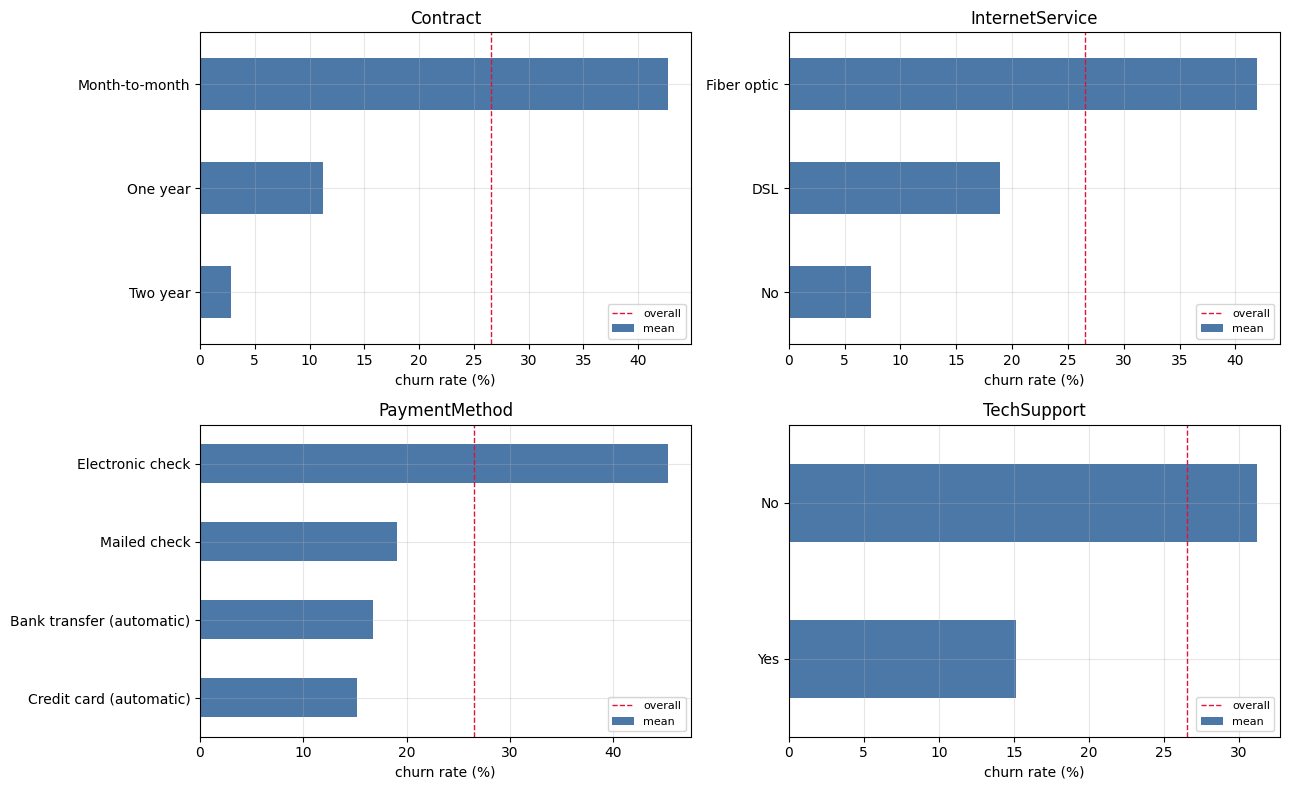

In [34]:
def churn_by(column, ax):
    g = df.groupby(column, observed=True)["Churn"].agg(["mean", "size"]).sort_values("mean")
    (g["mean"] * 100).plot(kind="barh", ax=ax, color="#4C78A8")
    ax.axvline(churn_rate * 100, color="crimson", ls="--", lw=1, label="overall")
    ax.set_xlabel("churn rate (%)"); ax.set_ylabel("")
    ax.set_title(column); ax.legend(fontsize=8)
    return g

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), ["Contract", "InternetService", "PaymentMethod", "TechSupport"]):
    churn_by(col, ax)
plt.tight_layout(); plt.show()

In [35]:
# The single widest split in the dataset.
df.groupby("Contract", observed=True)["Churn"].agg(
    customers="size", churned="sum", churn_rate="mean"
).assign(churn_rate=lambda d: (d["churn_rate"] * 100).round(2)).sort_values("churn_rate")

,customers,churned,churn_rate
Contract,,,
Two year,1695,48,2.83
One year,1473,166,11.27
Month-to-month,3875,1655,42.71


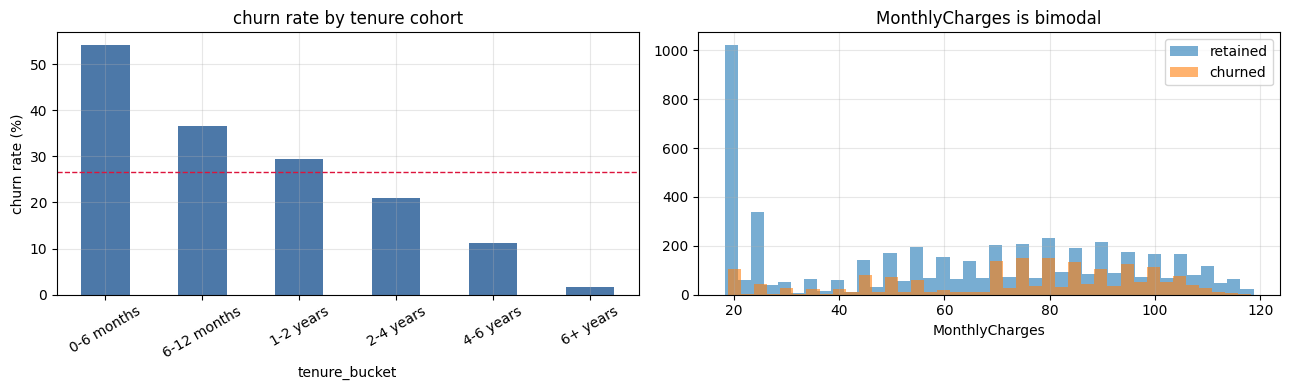

Two clusters: phone-only customers near $20, and fiber customers $70-$110.
Churn concentrates in the expensive cluster.


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bucket = df.groupby("tenure_bucket", observed=True)["Churn"].agg(["mean", "size"])
order = [b[2] for b in config.TENURE_BUCKETS if b[2] in bucket.index]
(bucket.loc[order, "mean"] * 100).plot(kind="bar", ax=axes[0], color="#4C78A8", rot=30)
axes[0].axhline(churn_rate * 100, color="crimson", ls="--", lw=1)
axes[0].set_title("churn rate by tenure cohort"); axes[0].set_ylabel("churn rate (%)")

for label, sub in df.groupby("Churn"):
    axes[1].hist(sub["MonthlyCharges"], bins=40, alpha=0.6,
                 label="churned" if label else "retained")
axes[1].set_title("MonthlyCharges is bimodal"); axes[1].set_xlabel("MonthlyCharges")
axes[1].legend()
plt.tight_layout(); plt.show()

print("Two clusters: phone-only customers near $20, and fiber customers $70-$110.")
print("Churn concentrates in the expensive cluster.")

In [37]:
# gender is inert. Worth showing explicitly -- if the model ever surfaces it as a
# top factor, something is wrong with the pipeline.
for col in ["gender", "Partner", "Dependents", "SeniorCitizen"]:
    g = df.groupby(col, observed=True)["Churn"].agg(["mean", "size"])
    spread = (g["mean"].max() - g["mean"].min()) * 100
    print(f"{col:<15} spread {spread:5.2f} pp   " +
          "  ".join(f"{i}={v:.1%}(n={int(n)})" for i, (v, n) in g.iterrows()))

gender          spread  0.76 pp   Female=26.9%(n=3488)  Male=26.2%(n=3555)
Partner         spread 13.29 pp   No=33.0%(n=3641)  Yes=19.7%(n=3402)
Dependents      spread 15.83 pp   No=31.3%(n=4933)  Yes=15.5%(n=2110)
SeniorCitizen   spread 18.08 pp   No=23.6%(n=5901)  Yes=41.7%(n=1142)


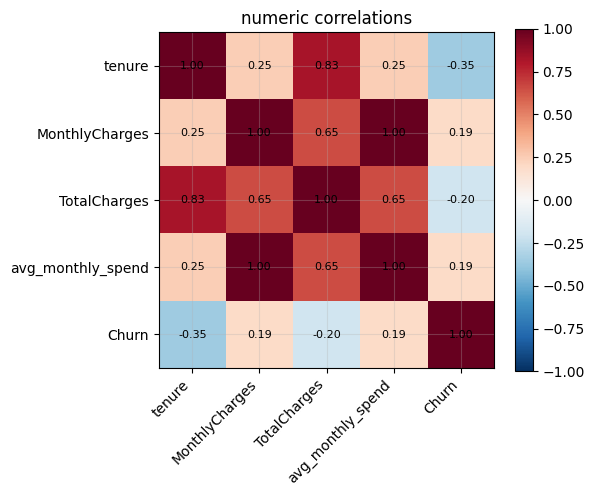

tenure is the strongest single numeric signal (-0.35).
TotalCharges correlates 0.83 with tenure -- overlapping information, kept for
the billing history it carries beyond tenure x MonthlyCharges.


In [38]:
numeric = config.NUMERIC_FEATURES + ["Churn"]
corr = df[numeric].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric))); ax.set_xticklabels(numeric, rotation=45, ha="right")
ax.set_yticks(range(len(numeric))); ax.set_yticklabels(numeric)
for i in range(len(numeric)):
    for j in range(len(numeric)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im); plt.title("numeric correlations"); plt.tight_layout(); plt.show()

print("tenure is the strongest single numeric signal (-0.35).")
print("TotalCharges correlates 0.83 with tenure -- overlapping information, kept for")
print("the billing history it carries beyond tenure x MonthlyCharges.")

## 4. Training and metric selection

`src/model/train.py` trains four candidates, selects between them, and persists the pipeline.
Running it here produces exactly the artifacts the app and the agent load — same code, same
`random_state`, same numbers.

In [39]:
from src.model.train import main as train_model

metrics = train_model()

[cv] dummy                          PR-AUC=0.2653 ROC-AUC=0.4999 Brier=0.1949 recall=1.0000
[cv] logistic_regression            PR-AUC=0.6560 ROC-AUC=0.8450 Brier=0.1353 recall=0.7880
[cv] logistic_regression_balanced   PR-AUC=0.6544 ROC-AUC=0.8449 Brier=0.1654 recall=0.7893
[cv] gradient_boosting              PR-AUC=0.6513 ROC-AUC=0.8420 Brier=0.1368 recall=0.7686

[select] best PR-AUC=0.6560; 3 candidate(s) within 0.01:
           logistic_regression            PR-AUC=0.6560 Brier=0.1353 max_cal_gap=0.118
           gradient_boosting              PR-AUC=0.6513 Brier=0.1368 max_cal_gap=0.046
           logistic_regression_balanced   PR-AUC=0.6544 Brier=0.1654 max_cal_gap=0.263
[select] -> logistic_regression (ranking tie broken on calibration)

[test] logistic_regression: PR-AUC=0.6358 ROC-AUC=0.8424 Brier=0.1379
       recall=0.7727 precision=0.5152 F2=0.7025 @ threshold=0.28

Saved pipeline.joblib, metrics.json, feature_meta.json to /content/churn-pred/artifacts


In [40]:
rows = []
for name, res in metrics["models"].items():
    cv = res["cv"]
    rows.append({"model": name, "PR-AUC": cv["pr_auc"], "ROC-AUC": cv["roc_auc"],
                 "Brier": cv["brier"], "max cal. gap": cv.get("max_calibration_gap"),
                 "recall": cv["recall"]})
pd.DataFrame(rows).set_index("model").sort_values("PR-AUC", ascending=False)

,PR-AUC,ROC-AUC,Brier,max cal. gap,recall
model,,,,,
logistic_regression,0.6560,0.8450,0.1353,0.1182,0.7880
logistic_regression_balanced,0.6544,0.8449,0.1654,0.2631,0.7893
gradient_boosting,0.6513,0.8420,0.1368,0.0463,0.7686
dummy,0.2653,0.4999,0.1949,0.0000,1.0000


### Why PR-AUC is the primary metric

**Accuracy is disqualified.** A do-nothing classifier scores 73.46%.

**Ranking matters more than any fixed threshold.** The agent's real questions — *who is most
likely to churn*, *which segment is riskiest* — are ordering problems, so the headline metric
must be threshold-free. Unlike ROC-AUC, PR-AUC is not flattered by the 73% negative class: its
baseline is the churn rate itself, so the lift is honest.

**Calibration is a correctness requirement, not a nicety.** This model is not a decision
system. It is a tool an LLM calls, whose output the agent *states to a user as a number*. A
model that says 65% for a group that churns 33% of the time reports a figure that is computed
but wrong — which arrives with an audit trail that makes it look verified.

So PR-AUC selects, and calibration gates: among candidates tied on ranking, best-calibrated wins.

In [41]:
# The finding that changed the design: class_weight="balanced" barely moves ranking
# and badly damages calibration.
lr = metrics["models"]["logistic_regression"]["cv"]
bal = metrics["models"]["logistic_regression_balanced"]["cv"]
print(f"{'':<22}{'unweighted':>12}{'balanced':>12}")
for key in ["pr_auc", "roc_auc", "brier", "max_calibration_gap"]:
    print(f"{key:<22}{lr[key]:>12.4f}{bal[key]:>12.4f}")
print("\nRanking is unaffected. Brier and the calibration gap are much worse when balanced,")
print("because reweighting inflates every predicted probability by roughly 1/base_rate.")

                        unweighted    balanced
pr_auc                      0.6560      0.6544
roc_auc                     0.8450      0.8449
brier                       0.1353      0.1654
max_calibration_gap         0.1182      0.2631

Ranking is unaffected. Brier and the calibration gap are much worse when balanced,
because reweighting inflates every predicted probability by roughly 1/base_rate.


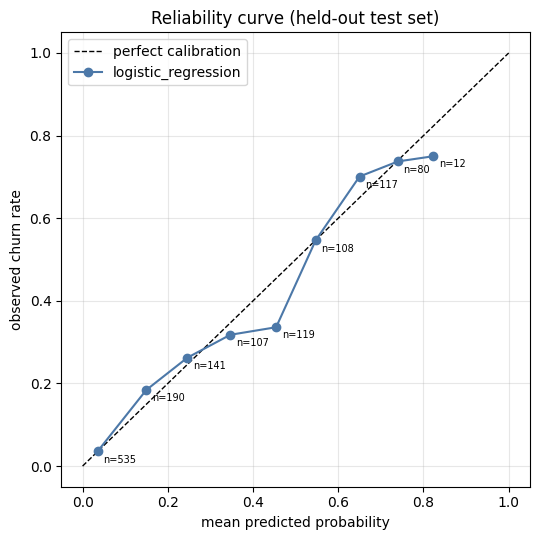

,bin_lower,bin_upper,n,mean_predicted,observed_rate
0,0.0,0.1,535,0.0351,0.0355
1,0.1,0.2,190,0.1495,0.1842
2,0.2,0.3,141,0.2460,0.2624
3,0.3,0.4,107,0.3467,0.3178
4,0.4,0.5,119,0.4542,0.3361
5,0.5,0.6,108,0.5469,0.5463
6,0.6,0.7,117,0.6499,0.7009
7,0.7,0.8,80,0.7402,0.7375
8,0.8,0.9,12,0.8226,0.7500


In [42]:
chosen = metrics["chosen_model"]
cal = pd.DataFrame(metrics["models"][chosen]["calibration"])

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
ax.plot(cal["mean_predicted"], cal["observed_rate"], "o-", color="#4C78A8", label=chosen)
for _, r in cal.iterrows():
    ax.annotate(f"n={int(r['n'])}", (r["mean_predicted"], r["observed_rate"]),
                fontsize=7, xytext=(4, -8), textcoords="offset points")
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("observed churn rate")
ax.set_title("Reliability curve (held-out test set)"); ax.legend()
plt.tight_layout(); plt.show()

cal

In [43]:
# The decision threshold is chosen by expected cost, not left at 0.5.
#
#   COST_FN_OVER_FP = (CLV_MARGIN x OFFER_SUCCESS_RATE) / OFFER_COST
#
# The offer-success term is the one usually omitted: catching a churner is only
# worth what the intervention actually recovers. Leaving it out inflates the
# ratio to 10:1 and drives the threshold to 0.18 -- flagging 68% of all customers.
print(f"cost ratio in use : {config.COST_FN_OVER_FP}")
print(f"threshold chosen  : {metrics['threshold']}")
print("\nsensitivity -- the assumption is load-bearing, so it is stated rather than buried:")
for ratio, thr in metrics["models"][chosen]["threshold_sensitivity"].items():
    print(f"  {ratio:<18} -> threshold {thr}")

test = metrics["models"][chosen]["test"]
print("\nheld-out test set:")
for key in ["pr_auc", "roc_auc", "brier", "recall", "precision", "f2"]:
    print(f"  {key:<10} {test[key]}")
print(" ", test["confusion_matrix"])

cost ratio in use : 3.0
threshold chosen  : 0.28

sensitivity -- the assumption is load-bearing, so it is stated rather than buried:
  cost_ratio_1       -> threshold 0.54
  cost_ratio_3       -> threshold 0.28
  cost_ratio_5       -> threshold 0.17
  cost_ratio_10      -> threshold 0.08
  cost_ratio_20      -> threshold 0.05

held-out test set:
  pr_auc     0.6358
  roc_auc    0.8424
  brier      0.1379
  recall     0.7727
  precision  0.5152
  f2         0.7025
  {'tn': 763, 'fp': 272, 'fn': 85, 'tp': 289}


## 5. The model as a callable tool

The point of Stage 1 is that the model does not stay in this notebook. The same functions the
agent calls are importable and usable here.

In [44]:
from src.model import service

result = service.predict_churn_risk("3668-QPYBK")
print(f"risk {result['risk_score']:.1%}  ({result['risk_band']}, "
      f"percentile {result['percentile']:.0f} of all customers)\n")
for f in result["top_factors"]:
    print(f"  {f['feature']:<18} = {str(f['value']):<16} {f['direction']:<10} "
          f"{f['contribution']:+.3f}")
    if f["note"]:
        print(f"      {f['note']}")

risk 29.2%  (Low, percentile 61 of all customers)

  tenure             = 2                increases  +1.770
      tenure of 2 sits in the 9th percentile (population median 29.00).
  TotalCharges       = 108.15           decreases  -0.660
      TotalCharges of 108.15 sits in the 12th percentile (population median 1394.55).
  InternetService    = DSL              decreases  -0.355
      InternetService=DSL customers churn at 19.0% vs 26.5% overall (n=2421).
  Contract           = Month-to-month   increases  +0.323
      Contract=Month-to-month customers churn at 42.7% vs 26.5% overall (n=3875).
  OnlineSecurity     = Yes              decreases  -0.280
      OnlineSecurity=Yes customers churn at 14.6% vs 26.5% overall (n=2019).


In [45]:
# Contributions are an EXACT decomposition, not an approximation: they sum to the
# predicted logit. That is why the agent can state them to a user as claims.
import math

pipeline, meta, _ = service._load_artifacts()
row = service.score_all_customers().query("customerID == '3668-QPYBK'").iloc[0]
frame = pd.DataFrame([row[config.MODEL_FEATURES].to_dict()])

x = np.asarray(pipeline.named_steps["prep"].transform(frame))[0]
coefs, means = np.asarray(meta["coefficients"]), np.asarray(meta["training_means"])
reconstructed = float((coefs * (x - means)).sum() + coefs @ means + meta["intercept"])
actual = math.log(row["risk_score"] / (1 - row["risk_score"]))

print(f"sum of contributions + reference : {reconstructed:.10f}")
print(f"logit of the predicted score     : {actual:.10f}")
print(f"difference                       : {abs(reconstructed - actual):.2e}")

sum of contributions + reference : -0.8845519910
logit of the predicted score     : -0.8845519910
difference                       : 3.33e-16


In [46]:
# What-if: the same customer on a two-year contract.
whatif = service.predict_churn_risk("3668-QPYBK", overrides={"Contract": "Two year"})
print(f"today            : {whatif['baseline_risk_score']:.1%}")
print(f"two-year contract: {whatif['risk_score']:.1%}")
print(f"change           : {whatif['risk_delta'] * 100:+.1f} percentage points")

today            : 29.2%
two-year contract: 9.7%
change           : -19.5 percentage points


In [47]:
# Aggregate risk across a segment. Predicted and observed are returned together,
# which gives a calibration check on every segment query for free.
seg = service.predict_segment_risk({
    "Contract": "Month-to-month",
    "InternetService": "Fiber optic",
    "PaymentMethod": "Electronic check",
})
print(f"customers        : {seg['n_customers']}")
print(f"mean predicted   : {seg['mean_risk']:.1%}")
print(f"actually churned : {seg['actual_churn_rate']:.1%}")
print(f"lift over base   : {seg['lift']}x")
print(f"\npredicted and observed agree to "
      f"{abs(seg['mean_risk'] - seg['actual_churn_rate']):.3f} -- the calibration work paying off")

customers        : 1307
mean predicted   : 60.5%
actually churned : 60.4%
lift over base   : 2.27x

predicted and observed agree to 0.001 -- the calibration work paying off


## 6. Summary

**Data issues found:** `TotalCharges` stored as text with 11 blanks invisible to `isnull()`
(all `tenure == 0`, so filled with 0 rather than the median); seven perfectly collinear
sentinel levels collapsed; `SeniorCitizen` recoded to match every other flag; 42
contradictory-label rows and 22 near-duplicates counted and deliberately kept; and no
`region`, date or product-category column, which the agent refuses by name rather than
inventing.

**Metric:** PR-AUC as the primary, because the agent's questions are ranking problems and
PR-AUC's baseline is the churn rate rather than the 73% negative class. Calibration gates the
choice, because the agent quotes these probabilities to users as numbers. Recall at a
cost-selected threshold reports the operational picture.

**Model:** unweighted logistic regression — test PR-AUC 0.636 against a 0.265 no-skill
baseline, well calibrated, and the only candidate giving an exact per-customer attribution.

The agent lives in the repository: a plan/act/verify loop, a restricted execution tool, a
numeric-grounding validator that rejects any figure not traceable to a computation, and a
critic pass that reviews whether the data supports the claim being made. See the README
for how planning and verification work.